In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

## Load & Understand the Data
**************************

In [2]:
x =np.array([50, 60, 70, 80, 90])
y =np.array([150, 180, 210, 240, 270]) # house price in thousands

- x represent input feature (independent variable)

- y represent the target feature (dependent variable)

## Create and Train the Model
*******************************

In [15]:
class LinearRegressionGD:
     def __init__(self,learning_rate=0.001, n_iters=100,degree=1):
          self.learning_rate=learning_rate
          self.n_iters=n_iters
          self.theta_0=0
          self.theta_1=0
          self.sse_value=[]
          self.alpha=0
          self.degree=degree
          self.poly=None
          self.weights=None

     def _is_poly(self):
        return self.degree > 1
     
     def fit(self, X, y):
        n_samples = len(X)

        if self._is_poly():
            
            self.poly = PolynomialFeatures(degree=self.degree)
            X_poly = self.poly.fit_transform(X.reshape(-1, 1))

            self.scaler = StandardScaler()
            X_poly = self.scaler.fit_transform(X_poly)  
            n_features = X_poly.shape[1]
            self.weights = np.zeros(n_features)  

            for _ in range(self.n_iters):
                y_pred = X_poly @ self.weights
                error = y_pred - y
                gradient = (2 / n_samples) * X_poly.T @ error
                self.weights -= self.learning_rate * gradient
                sse = np.sum(error ** 2)
                self.sse_value.append(sse)

            
            self.theta_0 = self.weights[0]
            self.theta_1 = self.weights[1]

        else:
        
         for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            
            
            d_theta_0 = (2/n_samples) * np.sum(y_pred - y)
            d_theta_1 = (2/n_samples) * np.sum(X * (y_pred - y))
            
            
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

            sse=np.sum((y_pred-y)**2)
            self.sse_value.append(sse)

     def predict(self, X):
         if self._is_poly():
            X_poly = self.poly.transform(X.reshape(-1, 1))
            X_poly = self.scaler.transform(X_poly)
            return X_poly @ self.weights
         return self.theta_0 + self.theta_1 * X
     
     def plot_training(self, X, y):
        
        
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(range(self.n_iters),self.sse_value,label='sse')
        plt.xlabel("Iterations")
        plt.ylabel("SSE")
        plt.title("SSE over Iterations")
        plt.legend()
        
       
        plt.subplot(1,2,2)
        plt.scatter(X, y)
        if self._is_poly():
            X_sorted = np.sort(X)
            y_pred = self.predict(X_sorted)
            plt.plot(X_sorted, y_pred, color='red',
                     label=f'Poly Degree {self.degree}')
        else:
           y_pred = self.predict(np.array(X))
           plt.plot(X, y_pred)
        plt.xlabel("House Size (m²)")
        plt.ylabel("Price (thousands)")
        plt.title("Regression Line")
        plt.show()

     def calc_MSE(self,x,y):
         y_pred= self.predict(x)
         return mean_squared_error(y,y_pred)
     
     def lasso_reg(self,x,y,alpha):
         lin_lasso=Lasso(alpha=self.alpha)
         lin_lasso.fit(x,y)
         return lin_lasso.predict(x)
     def ridge_reg(self,x,y):
         lin_ridge = Ridge(alpha=self.alpha)
         lin_ridge.fit(x,y)
         return lin_ridge.predict(x)
          

In [5]:
modl=LinearRegressionGD(learning_rate=0.001,n_iters=100)
modl.fit(x, y)

print("theta_0:", modl.theta_0)
print("theta_1:", modl.theta_1)


theta_0: -1.0055957901462392e+95
theta_1: -7.326427288635144e+96


- theta_0 represent intercept

- theta_1 represent slope

## Prediction
*********************

In [6]:
modl.predict(70)

np.float64(-5.129504697834747e+98)

isn't reasonable because the learning rate is  big and the number of iteration is small

## Visualization

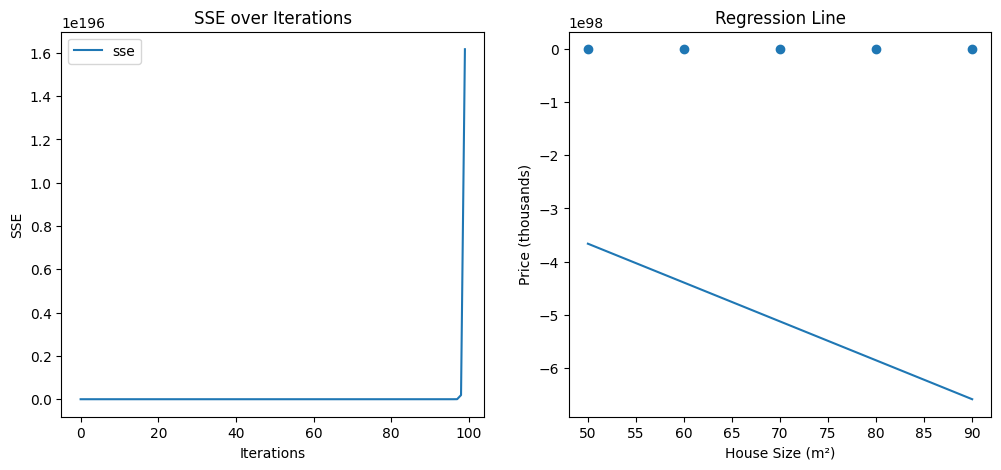

In [7]:
modl.plot_training(x,y)

- Why SSE decreases over time?

 because as the time pass the model learn more and the predicted values get closer to the true values so the sse decrease


- What convergence means in Gradient Descent?

 convergence means the algorithm has reached the minimum error, and further updates do not significantly change the parameter

### Experimentation

C:\Users\tasne\AppData\Local\Temp\ipykernel_1556\1402552175.py:54: RuntimeWarning: overflow encountered in square
  sse=np.sum((y_pred-y)**2)


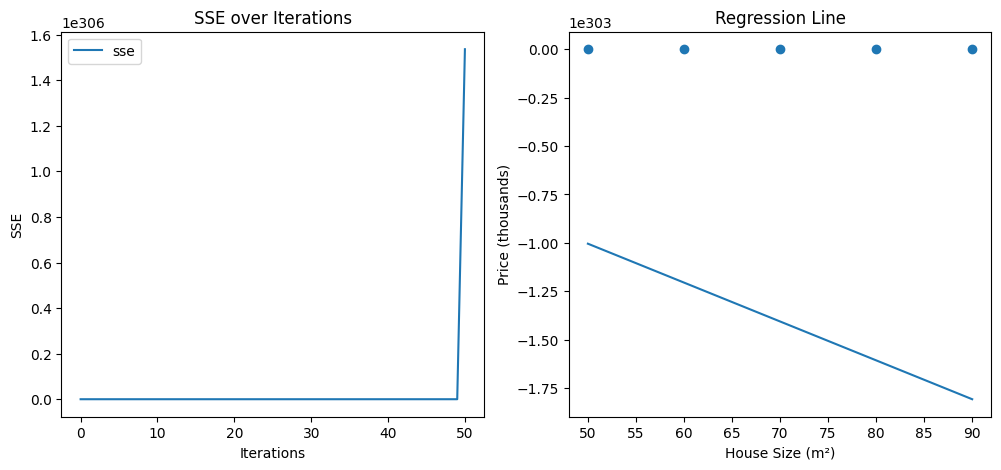

In [8]:
model_large = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_large.fit(x, y)
model_large.plot_training(x, y)


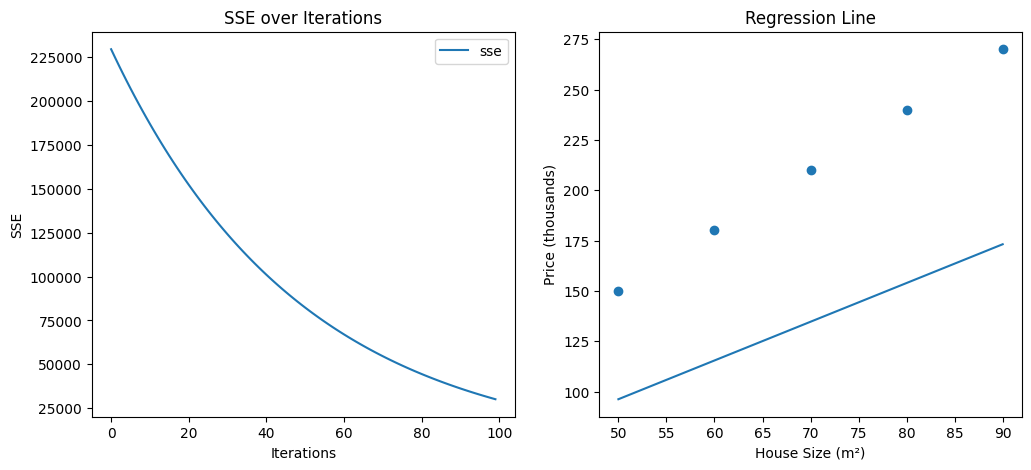

In [9]:
model_small = LinearRegressionGD(learning_rate=1e-6, n_iters=100)
model_small.fit(x, y)
model_small.plot_training(x, y)


what happen if the learning rate is too large:

SSE increases instead of decreasing.

Parameters become extremely large.

The algorithm diverges.

The model fails to converge.

